In [1]:
import pandas as pd
import pickle
import os
import random
from tqdm.auto import tqdm
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transliterate import translit
import nlpaug.augmenter.char as nac

tqdm.pandas()

TRAIN_BIO_PATH = "../../data/processed/train_bio.csv"
VAL_BIO_PATH = "../../data/processed/validation_bio.csv"
LIBRARY_PATH = "../../data/external/hybrid_library.pkl"

FINAL_TRAIN_PATH = "../../data/processed/final_train.csv"
FINAL_VAL_PATH = "../../data/processed/final_val.csv"

NUM_SYNTHETIC_SAMPLES = 10000

print("--- Шаг 1: Загрузка данных ---")
df_train_real = pd.read_csv(TRAIN_BIO_PATH, sep=";")
df_train_real["tokens"] = df_train_real["tokens"].apply(eval)
df_train_real["tags"] = df_train_real["tags"].apply(eval)

df_val_real = pd.read_csv(VAL_BIO_PATH, sep=";")
df_val_real["tokens"] = df_val_real["tokens"].apply(eval)
df_val_real["tags"] = df_val_real["tags"].apply(eval)

with open(LIBRARY_PATH, 'rb') as f:
    master_artefacts = pickle.load(f)
hybrid_library = master_artefacts['hybrid_library']

print("Данные для генерации успешно загружены.")

--- Шаг 1: Загрузка данных ---
Данные для генерации успешно загружены.


In [2]:
print("--- Шаг 2: Создание Ультимативного Арсенала Аугментаторов ---")


def augment_on_fly(text):
    if random.random() < 0.2:
        return typo_augmenter.augment(text)[0]
    return text


def augment_case(text: str) -> str:
    r = random.random()
    if r < 0.25: return text.lower()
    if r < 0.5: return text.upper()
    if r < 0.75: return text.title()
    return text


typo_augmenter = nac.KeyboardAug(aug_char_p=0.05, aug_word_p=0.1, include_special_char=False)


def augment_typos(text: str) -> str:
    result = typo_augmenter.augment(text)
    return result[0] if isinstance(result, list) else result


def augment_translit(text: str) -> str:
    if not re.search('[а-яА-Я]', text): return text
    try:
        return translit(text, 'ru', reversed=True)
    except Exception:
        return text


def augment_spacing(text: str) -> str:
    r = random.random()
    if r < 0.5:
        return text.replace(" ", "")
    else:
        return re.sub(r'(\d)([а-яА-Яa-zA-Z%])', r'\1 \2', text)


def augment_permutation(entities: list) -> list:
    permuted = entities[:]
    random.shuffle(permuted)
    return permuted


noise_words = [
    "купить", "продать", "цена", "стоимость", "недорого", "дёшево", "дорого",
    "онлайн", "интернет", "магазин", "доставка", "скидка", "акция", "распродажа",
    "найти", "искать", "заказать", "пожалуйста", "нужно", "хочу", "можно",
    "какой", "сколько", "где", "когда", "зачем", "почему", "как",
    "лучший", "хороший", "отличный", "свежий", "новый", "старый",

    "в", "на", "по", "с", "к", "из", "от", "до", "за", "через", "над", "под",
    "между", "около", "у", "при", "без", "после", "для", "о",

    "и", "а", "но", "или", "так", "чтобы", "если", "хотя", "потому", "что",
    "как", "также",

    "я", "ты", "он", "она", "оно", "мы", "вы", "они", "мой", "твой", "его",
    "её", "наш", "ваш", "их", "себя", "кто", "что", "где", "когда", "зачем",
    "кто-то", "что-то", "каждый", "весь", "всякий", "любой", "сам",

    "не", "ни", "да", "нет", "вот", "вон", "же", "ли", "только", "уже",
    "ещё", "очень", "совсем", "просто", "именно", "всё", "всё-таки", "ну",

    "быть", "есть", "был", "была", "были", "будет", "будут", "стать", "стало",

    "это", "эти", "тот", "та", "те", "тут", "там", "сейчас", "сегодня", "вчера",
    "завтра"
]


def augment_add_noise(entities: list) -> list:
    if not noise_words:
        return entities
    noisy_entities = entities[:]
    insert_position = random.randint(0, len(noisy_entities))
    noisy_entities.insert(insert_position, (random.choice(noise_words), 'O'))
    return noisy_entities


print("Функции-аугментаторы успешно определены.")

--- Шаг 2: Создание Ультимативного Арсенала Аугментаторов ---
Функции-аугментаторы успешно определены.


In [3]:
print("\n--- Шаг 3: Запуск 'Фабрики Синтетики' с Полным Конвейером Аугментаций ---")

raw_synthetic_data = []
synthetic_data = []

AUGMENTATION_PROBS = {
    "TYPE": 0.6,
    "BRAND": 0.7,
    "VOLUME": 0.8,
    "PERCENT": 0.8
}
PERMUTATION_PROB = 0.5
ADD_NOISE_PROB = 0.15
TRANSLIT_PROB = 0.2
TYPO_PROB = 0.5

eligible_categories = [cat for cat, data in hybrid_library.items() if data.get('volumes') or data.get('percents')]
print(f"Найдено {len(eligible_categories)} категорий, подходящих для генерации.")

templates = [
    ["TYPE", "BRAND", "VOLUME"], ["TYPE", "BRAND", "PERCENT"],
    ["BRAND", "TYPE", "VOLUME", "PERCENT"], ["TYPE", "VOLUME"],
    ["TYPE", "PERCENT"], ["BRAND", "TYPE"]
]

for _ in tqdm(range(NUM_SYNTHETIC_SAMPLES), desc="Генерация синтетики"):
    if not eligible_categories: break

    category_key = random.choice(eligible_categories)
    components = hybrid_library[category_key]
    entity_map = {"TYPE": category_key}

    if components.get('brands'): entity_map["BRAND"] = random.choice(components['brands'])

    use_volume = len(components.get('volumes', [])) > 0 and random.random() < 0.8
    use_percent = len(components.get('percents', [])) > 0 and random.random() < 0.6
    if use_volume: entity_map["VOLUME"] = random.choice(components['volumes'])
    if use_percent: entity_map["PERCENT"] = random.choice(components['percents'])
    if "VOLUME" not in entity_map and "PERCENT" not in entity_map:
        if components.get('volumes'):
            entity_map["VOLUME"] = random.choice(components['volumes'])
        elif components.get('percents'):
            entity_map["PERCENT"] = random.choice(components['percents'])
        else:
            continue

    available_labels = list(entity_map.keys())
    possible_templates = [t for t in templates if all(label in available_labels for label in t)]
    if not possible_templates: continue
    chosen_template = random.choice(possible_templates)

    query_entities = []
    for label in chosen_template:
        entity_text = entity_map[label]

        if random.random() < AUGMENTATION_PROBS.get(label, 0.3):
            augmented_text = entity_text

            if random.random() < TRANSLIT_PROB:
                augmented_text = augment_translit(augmented_text)
            else:
                augmented_text = augment_case(augmented_text)
                if random.random() < TYPO_PROB:
                    augmented_text = augment_typos(augmented_text)

            if label in ["VOLUME", "PERCENT"]:
                augmented_text = augment_spacing(augmented_text)

            query_entities.append((augmented_text, label))
        else:
            query_entities.append((entity_text, label))

    if len(query_entities) > 1 and random.random() < PERMUTATION_PROB:
        query_entities = augment_permutation(query_entities)

    if random.random() < ADD_NOISE_PROB:
        query_entities = augment_add_noise(query_entities)

    query_entities = [(augment_on_fly(t[0]), t[1]) for t in query_entities]

    final_sample_text = ""
    annotations = []
    current_pos = 0

    for text, label in query_entities:
        start_pos = current_pos
        final_sample_text += text
        end_pos = current_pos + len(text)

        if label != 'O':
            annotations.append((start_pos, end_pos, f"B-{label}"))  # Упрощенно, B- для всех

        # Добавляем пробел
        final_sample_text += " "
        current_pos = end_pos + 1

    final_sample_text = final_sample_text.strip()

    if final_sample_text:
        raw_synthetic_data.append({'sample': final_sample_text, 'annotation': annotations})

print(f"Сгенерировано {len(raw_synthetic_data)} сырых синтетических примеров.")
df_synthetic_raw = pd.DataFrame(raw_synthetic_data)


--- Шаг 3: Запуск 'Фабрики Синтетики' с Полным Конвейером Аугментаций ---
Найдено 169 категорий, подходящих для генерации.


Генерация синтетики:   0%|          | 0/10000 [00:00<?, ?it/s]

Сгенерировано 10000 сырых синтетических примеров.


In [4]:
from src.data_converter import indices_to_bio, sanitize_annotations


def fix_zero_tags(annotations: list) -> list:
    return [(start, end, "O" if label == "0" else label) for start, end, label in annotations]


# 1. Загружаем ОРИГИНАЛЬНЫЙ train.csv
df_train_original_raw = pd.read_csv("../../data/raw/train.csv", sep=";")
df_train_original_raw["annotation"] = df_train_original_raw["annotation"].apply(eval)

# 2. Объединяем реальные и синтетические сырые данные
df_full_raw = pd.concat([df_train_original_raw, df_synthetic_raw], ignore_index=True)
print(f"Объединенный сырой датасет содержит {len(df_full_raw)} примеров.")

# 3. Применяем ЕДИНЫЙ конвейер обработки ко ВСЕМУ
df_full_raw['annotation'] = df_full_raw['annotation'].apply(fix_zero_tags)
df_full_raw['annotation'] = df_full_raw.apply(lambda r: sanitize_annotations(r['sample'], r['annotation'])[1], axis=1)

processed_bio = df_full_raw.progress_apply(
    lambda row: indices_to_bio(row["sample"], row["annotation"]), axis=1
)
df_full_bio = pd.DataFrame(processed_bio.tolist(), columns=["tokens", "tags"])
df_full_bio['sample'] = df_full_raw['sample'].values

from sklearn.model_selection import train_test_split


def get_stratify_key(tags):
    b_tags = sorted([t for t in tags if t.startswith('B-')])
    return "_".join(b_tags) if b_tags else "O_only"


print("\n--- Шаг 4: Выполнение 'умного' стратифицированного разбиения ---")
df_full_bio['stratify_key'] = df_full_bio['tags'].apply(get_stratify_key)

stratify_counts = df_full_bio['stratify_key'].value_counts()

# 2. Находим "одиночек"
single_member_classes = stratify_counts[stratify_counts < 2].index  # Берем все, что меньше 2
if not single_member_classes.empty:
    print(
        f"Предупреждение: Найдено {len(single_member_classes)} страт с одним элементом. Они будут отнесены только к обучающей выборке.")

    # 3. Разделяем датасет на "нормальный" и "одиночек"
    df_stratifiable = df_full_bio[~df_full_bio['stratify_key'].isin(single_member_classes)]
    df_singletons = df_full_bio[df_full_bio['stratify_key'].isin(single_member_classes)]
else:
    print("Проверка пройдена: все страты имеют 2 или более элементов.")
    df_stratifiable = df_full_bio
    df_singletons = pd.DataFrame()

train_df_strat, val_df = train_test_split(
    df_stratifiable,
    test_size=0.15,
    random_state=42,
    stratify=df_stratifiable['stratify_key']
)

train_df = pd.concat([train_df_strat, df_singletons], ignore_index=True).sample(frac=1, random_state=42)
train_df = train_df.drop(columns=['stratify_key'])
val_df = val_df.drop(columns=['stratify_key'])

train_df.to_csv(FINAL_TRAIN_PATH, sep=";", index=False)
val_df.to_csv(FINAL_VAL_PATH, sep=";", index=False)

print("\nФинальные консистентные датасеты для обучения и валидации созданы.")

Объединенный сырой датасет содержит 37251 примеров.


  0%|          | 0/37251 [00:00<?, ?it/s]


--- Шаг 4: Выполнение 'умного' стратифицированного разбиения ---
Предупреждение: Найдено 4 страт с одним элементом. Они будут отнесены только к обучающей выборке.

Финальные консистентные датасеты для обучения и валидации созданы.



--- Шаг 5: Финальный анализ распределения сущностей в новых датасетах ---
Сравнение количества сущностей (B-тегов) в датасетах:
dataset  Исходный Train  Финальный Train  Финальный Val
entity                                                 
BRAND              6556             7113           1254
PERCENT              29             1186            210
TYPE              24688            33149           5851
VOLUME               67             7161           1263

График сравнения сохранен в: ../../reports/figures/final_dataset_distribution_v1.png


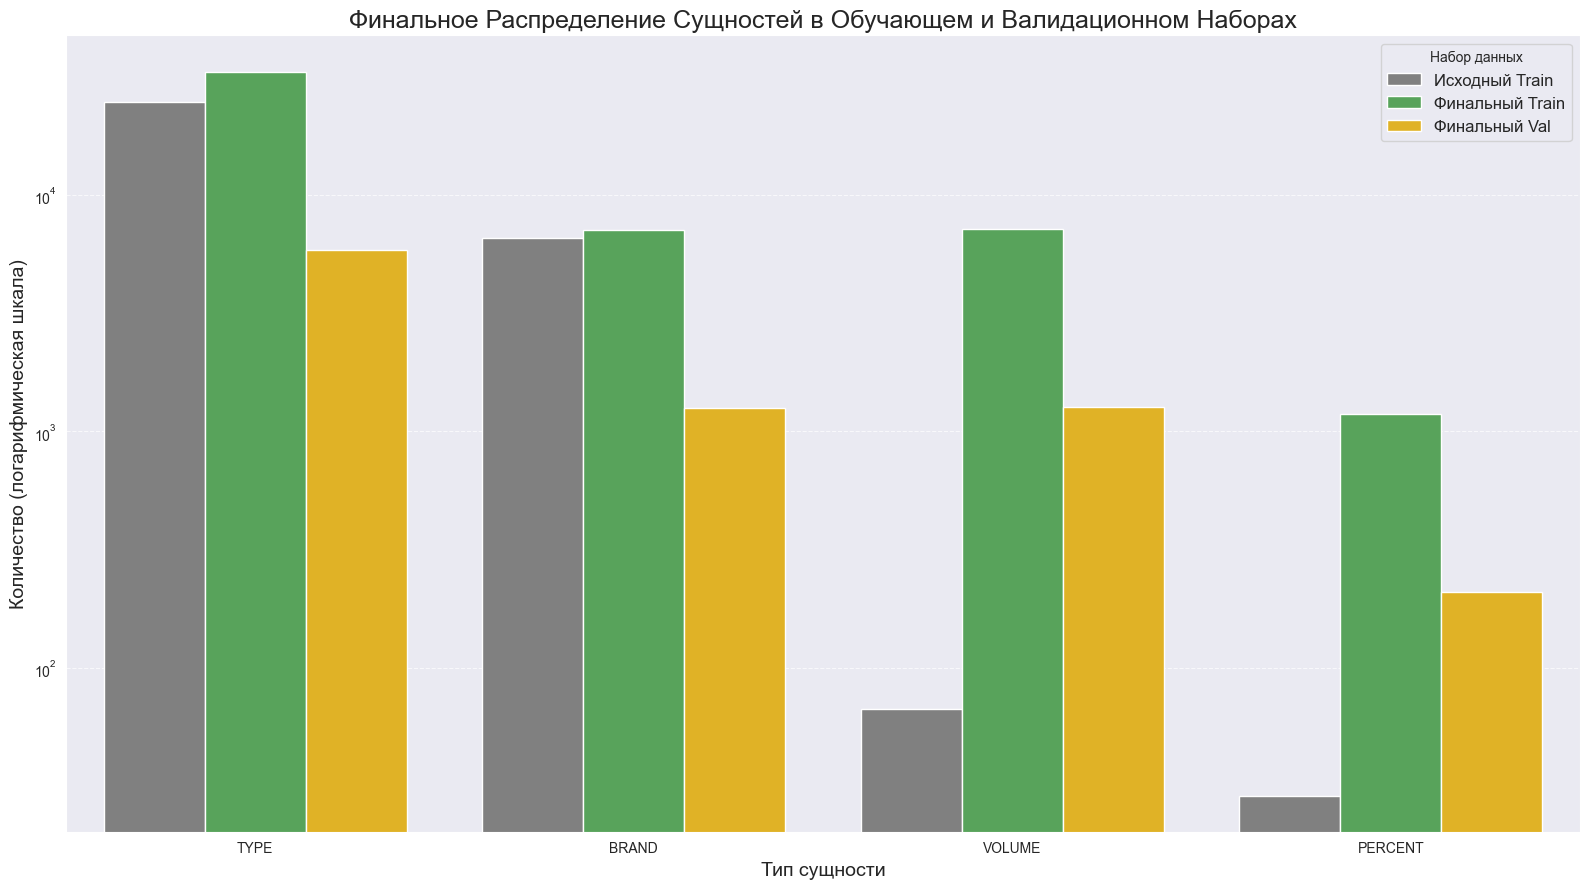

In [5]:

print("\n--- Шаг 5: Финальный анализ распределения сущностей в новых датасетах ---")


def count_entities(df, name=""):
    counts = Counter()
    tags_series = df['tags'].apply(lambda x: x if isinstance(x, list) else eval(str(x)))

    for tags_list in tags_series:
        for tag in tags_list:
            if tag.startswith("B-"):
                counts[tag[2:]] += 1

    df_counts = pd.DataFrame.from_dict(counts, orient='index', columns=['count']).reset_index()
    df_counts = df_counts.rename(columns={'index': 'entity'})
    df_counts['dataset'] = name
    return df_counts


original_train_counts_df = count_entities(df_train_real, name="Исходный Train")
final_train_counts_df = count_entities(train_df, name="Финальный Train")
final_val_counts_df = count_entities(val_df, name="Финальный Val")

comparison_df = pd.concat([original_train_counts_df, final_train_counts_df, final_val_counts_df])

print("Сравнение количества сущностей (B-тегов) в датасетах:")
pivot_table = comparison_df.pivot_table(index='entity', columns='dataset', values='count', fill_value=0).astype(int)
pivot_table = pivot_table[['Исходный Train', 'Финальный Train', 'Финальный Val']]
print(pivot_table)

plt.figure(figsize=(16, 9))
sns.barplot(data=comparison_df, x='entity', y='count', hue='dataset',
            palette={'Исходный Train': 'grey', 'Финальный Train': '#4CAF50', 'Финальный Val': '#FFC107'})
plt.title('Финальное Распределение Сущностей в Обучающем и Валидационном Наборах', fontsize=18)
plt.xlabel('Тип сущности', fontsize=14)
plt.ylabel('Количество (логарифмическая шкала)', fontsize=14)
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Набор данных', fontsize='large')
plt.tight_layout()

output_chart_path = "../../reports/figures/final_dataset_distribution_v1.png"
os.makedirs(os.path.dirname(output_chart_path), exist_ok=True)
plt.savefig(output_chart_path)
print(f"\nГрафик сравнения сохранен в: {output_chart_path}")

plt.show()